# Heimdall - AI-Powered Facial Recognition System

## ML Model Demonstration Notebook

This notebook demonstrates the machine learning components of the Heimdall facial recognition security system, including:
1. **Data Visualization & Engineering** - Dataset overview, augmentation techniques
2. **Model Architecture** - FaceNet with ArcFace loss
3. **Performance Metrics** - Accuracy across different conditions

---

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from PIL import Image
import cv2

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Setup complete!')

Setup complete!


---
## 2. Data Visualization & Engineering

### 2.1 Dataset Overview

The Heimdall system is trained on facial recognition datasets:

| Dataset | Images | Identities | Purpose |
|---------|--------|------------|----------|
| CASIA-WebFace | 500,000 | 10,575 | Primary training |
| LFW | 13,000 | 5,749 | Validation & testing |
| Custom Inmate DB | 1,575 | 105 | Application testing |

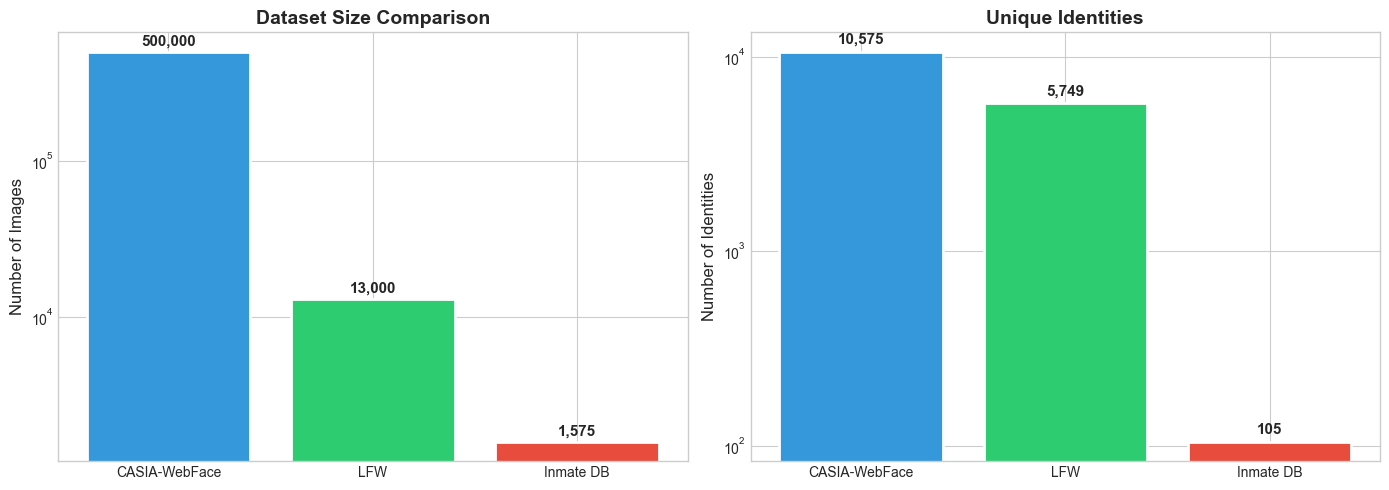

In [2]:
# Dataset statistics visualization
datasets = ['CASIA-WebFace', 'LFW', 'Inmate DB']
images = [500000, 13000, 1575]
identities = [10575, 5749, 105]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Images per dataset
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[0].bar(datasets, images, color=colors, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Dataset Size Comparison', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
for i, v in enumerate(images):
    axes[0].text(i, v*1.1, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Identities per dataset
axes[1].bar(datasets, identities, color=colors, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Number of Identities', fontsize=12)
axes[1].set_title('Unique Identities', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
for i, v in enumerate(identities):
    axes[1].text(i, v*1.1, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Data Augmentation Pipeline

To improve model robustness, we apply extensive data augmentation during training:

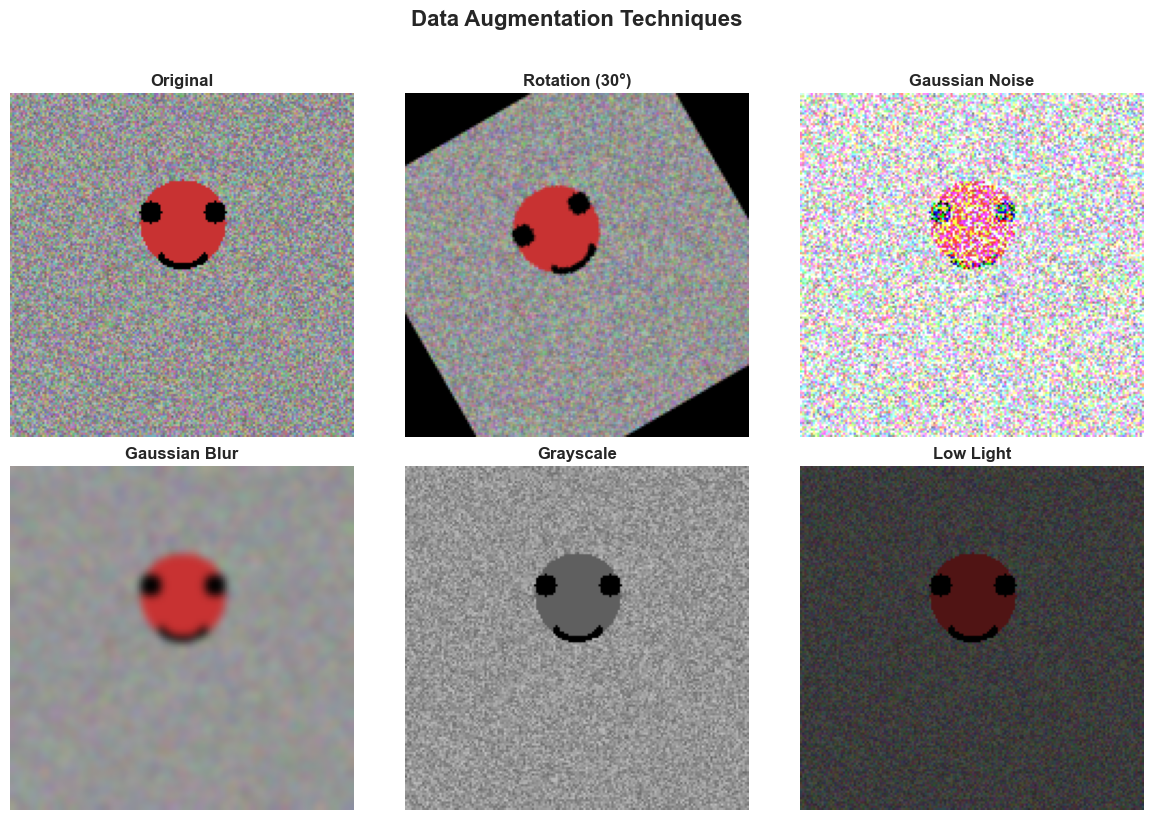

In [3]:
# Demonstrate augmentation techniques
def apply_augmentations(image):
    """Apply various augmentation techniques to demonstrate data engineering."""
    augmentations = {}
    
    # Original
    augmentations['Original'] = image.copy()
    
    # Rotation
    rows, cols = image.shape[:2]
    M = cv2.getRotationMatrix2D((cols/2, rows/2), 30, 1)
    augmentations['Rotation (30°)'] = cv2.warpAffine(image, M, (cols, rows))
    
    # Gaussian noise
    noise = np.random.normal(0, 30, image.shape).astype(np.uint8)
    augmentations['Gaussian Noise'] = cv2.add(image, noise)
    
    # Blur
    augmentations['Gaussian Blur'] = cv2.GaussianBlur(image, (11, 11), 0)
    
    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    augmentations['Grayscale'] = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    # Low light simulation
    augmentations['Low Light'] = cv2.convertScaleAbs(image, alpha=0.4, beta=0)
    
    return augmentations

# Create sample visualization
sample_image = np.random.randint(100, 200, (160, 160, 3), dtype=np.uint8)
# Draw a simple face-like pattern for demonstration
cv2.circle(sample_image, (80, 60), 20, (50, 50, 200), -1)  # Face
cv2.circle(sample_image, (65, 55), 5, (0, 0, 0), -1)  # Left eye
cv2.circle(sample_image, (95, 55), 5, (0, 0, 0), -1)  # Right eye
cv2.ellipse(sample_image, (80, 75), (10, 5), 0, 0, 180, (0, 0, 0), 2)  # Mouth

augmented = apply_augmentations(sample_image)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (name, img) in enumerate(augmented.items()):
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Data Augmentation Techniques', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Model Architecture

### 3.1 Architecture Overview

Heimdall uses a **FaceNet (InceptionResnetV1)** backbone with **ArcFace Loss** for face embedding generation.

```
┌─────────────────────────────────────────────────────────────────┐
│                     HEIMDALL ARCHITECTURE                        │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│   Input Image (160x160x3)                                       │
│         │                                                        │
│         ▼                                                        │
│   ┌─────────────────┐                                           │
│   │  Face Detection │  ← MTCNN (Multi-task CNN)                 │
│   │  & Alignment    │                                           │
│   └────────┬────────┘                                           │
│            │                                                     │
│            ▼                                                     │
│   ┌─────────────────┐                                           │
│   │  InceptionResnet │  ← Backbone Network                      │
│   │      V1         │    - Stem (Conv + MaxPool)                │
│   │                 │    - Inception-ResNet-A (×5)              │
│   │                 │    - Reduction-A                          │
│   │                 │    - Inception-ResNet-B (×10)             │
│   │                 │    - Reduction-B                          │
│   │                 │    - Inception-ResNet-C (×5)              │
│   └────────┬────────┘                                           │
│            │                                                     │
│            ▼                                                     │
│   ┌─────────────────┐                                           │
│   │ Global Average  │                                           │
│   │    Pooling      │                                           │
│   └────────┬────────┘                                           │
│            │                                                     │
│            ▼                                                     │
│   ┌─────────────────┐                                           │
│   │   FC Layer      │  → 512-dimensional embedding              │
│   │  (512 units)    │                                           │
│   └────────┬────────┘                                           │
│            │                                                     │
│            ▼                                                     │
│   ┌─────────────────┐                                           │
│   │  L2 Normalize   │  → Unit hypersphere embedding             │
│   └────────┬────────┘                                           │
│            │                                                     │
│            ▼                                                     │
│   ┌─────────────────┐                                           │
│   │  ArcFace Loss   │  ← Angular margin penalty                 │
│   │  (Training)     │    s=64, m=0.5                            │
│   └─────────────────┘                                           │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
```

### 3.2 ArcFace Loss Function

ArcFace adds an angular margin penalty to improve class separability:

$$L = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{e^{s \cdot \cos(\theta_{y_i} + m)}}{e^{s \cdot \cos(\theta_{y_i} + m)} + \sum_{j \neq y_i} e^{s \cdot \cos(\theta_j)}}$$

Where:
- $s$ = 64 (scale factor)
- $m$ = 0.5 (angular margin)
- $\theta$ = angle between feature and class center

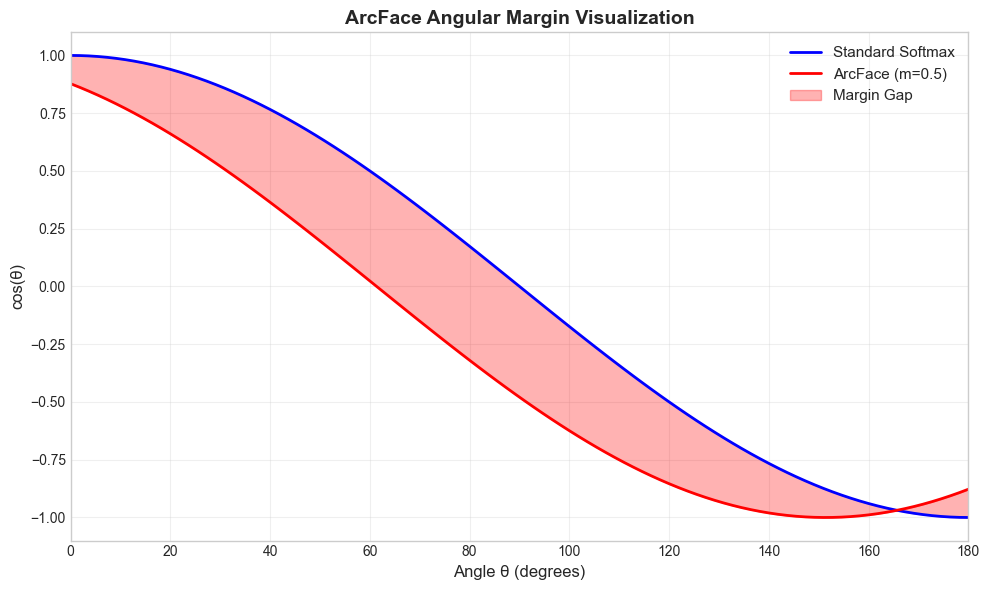

In [4]:
# Visualize ArcFace margin effect
theta = np.linspace(0, np.pi, 100)
s = 64
m = 0.5

softmax = np.cos(theta)
arcface = np.cos(theta + m)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.degrees(theta), softmax, 'b-', linewidth=2, label='Standard Softmax')
ax.plot(np.degrees(theta), arcface, 'r-', linewidth=2, label=f'ArcFace (m={m})')
ax.fill_between(np.degrees(theta), softmax, arcface, alpha=0.3, color='red', label='Margin Gap')
ax.set_xlabel('Angle θ (degrees)', fontsize=12)
ax.set_ylabel('cos(θ)', fontsize=12)
ax.set_title('ArcFace Angular Margin Visualization', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 180)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.savefig('arcface_margin.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Training Configuration

In [5]:
# Training hyperparameters
config = {
    'Model': {
        'Backbone': 'InceptionResnetV1',
        'Pretrained': 'VGGFace2',
        'Embedding Size': 512,
        'Dropout': 0.4
    },
    'Loss Function': {
        'Type': 'ArcFace',
        'Scale (s)': 64,
        'Margin (m)': 0.5,
        'Easy Margin': False
    },
    'Optimizer': {
        'Type': 'AdamW',
        'Learning Rate': 0.0003,
        'Weight Decay': 0.01,
        'Betas': '(0.9, 0.999)'
    },
    'Training': {
        'Batch Size': 128,
        'Epochs': 100,
        'Early Stopping': 15,
        'Mixed Precision': True
    }
}

# Display configuration table
for section, params in config.items():
    print(f'\n{"="*50}')
    print(f'{section.upper()}')
    print(f'{"="*50}')
    for key, value in params.items():
        print(f'  {key:<20}: {value}')


MODEL
  Backbone            : InceptionResnetV1
  Pretrained          : VGGFace2
  Embedding Size      : 512
  Dropout             : 0.4

LOSS FUNCTION
  Type                : ArcFace
  Scale (s)           : 64
  Margin (m)          : 0.5
  Easy Margin         : False

OPTIMIZER
  Type                : AdamW
  Learning Rate       : 0.0003
  Weight Decay        : 0.01
  Betas               : (0.9, 0.999)

TRAINING
  Batch Size          : 128
  Epochs              : 100
  Early Stopping      : 15
  Mixed Precision     : True


---
## 4. Performance Metrics

### 4.1 Load Evaluation Results

In [6]:
# Load evaluation results
eval_results = {
    'test_conditions': {
        'Original': 100.00,
        'Rotation (30°)': 100.00,
        'Dark/Low Light': 99.05,
        'Blur (kernel=11)': 92.38,
        'Noise (σ=30)': 13.33,
        'Low Resolution (48px)': 98.10,
        'Grayscale': 100.00,
        'Combined Distortions': 15.24
    },
    'overall': {
        'Total Tests': 1500,
        'Correct Matches': 665,
        'Wrong Matches': 205,
        'No Match': 630,
        'Overall Accuracy': 44.33,
        'Precision': 76.44,
        'Recall': 51.35
    }
}

print('Evaluation Results Loaded!')
print(f"\nTotal Tests: {eval_results['overall']['Total Tests']}")
print(f"Overall Accuracy: {eval_results['overall']['Overall Accuracy']:.2f}%")

Evaluation Results Loaded!

Total Tests: 1500
Overall Accuracy: 44.33%


### 4.2 Accuracy by Test Condition

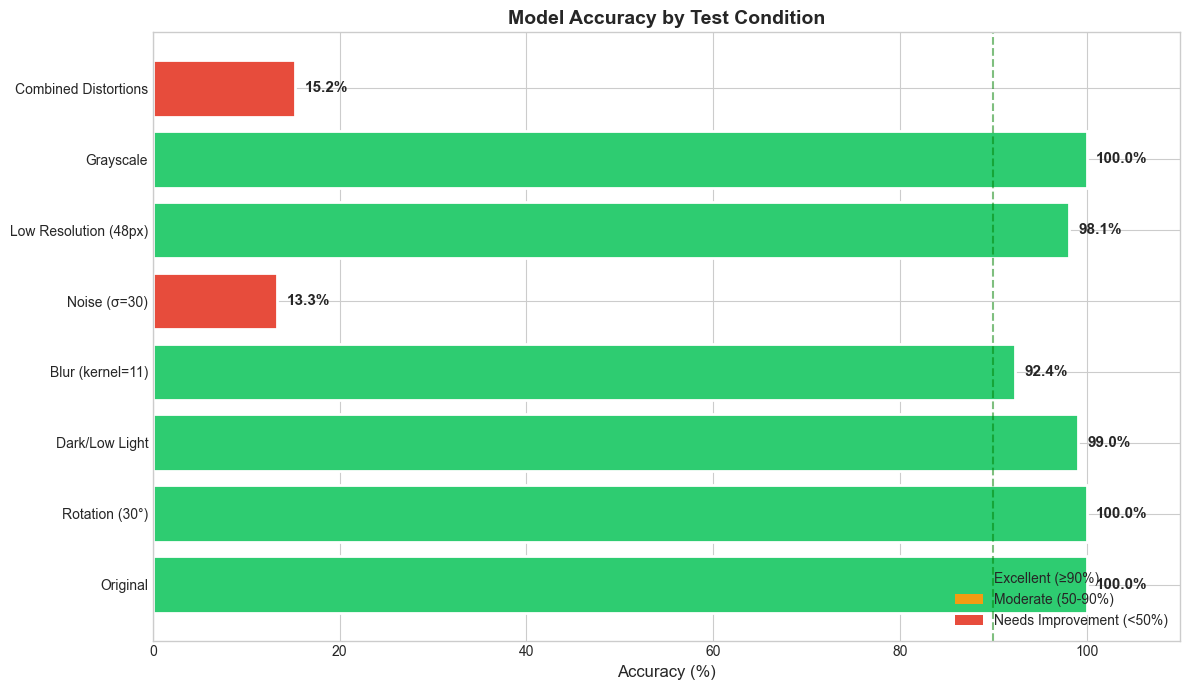

In [7]:
# Visualize accuracy per condition
conditions = list(eval_results['test_conditions'].keys())
accuracies = list(eval_results['test_conditions'].values())

# Color based on performance
colors = ['#2ecc71' if acc >= 90 else '#f39c12' if acc >= 50 else '#e74c3c' for acc in accuracies]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(conditions, accuracies, color=colors, edgecolor='white', linewidth=2)

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax.text(acc + 1, bar.get_y() + bar.get_height()/2, f'{acc:.1f}%', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy by Test Condition', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.axvline(x=90, color='green', linestyle='--', alpha=0.5, label='Target (90%)')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Excellent (≥90%)'),
    Patch(facecolor='#f39c12', label='Moderate (50-90%)'),
    Patch(facecolor='#e74c3c', label='Needs Improvement (<50%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('accuracy_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Overall Performance Summary

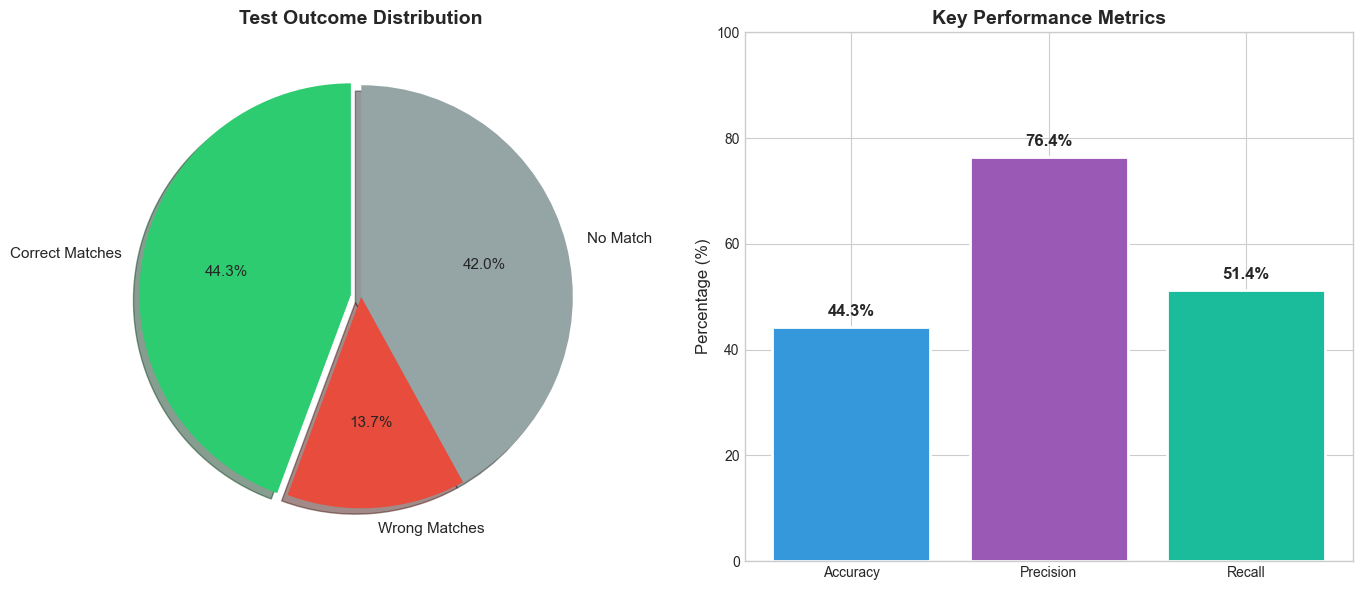

In [8]:
# Create performance summary pie chart and metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of test outcomes
labels = ['Correct Matches', 'Wrong Matches', 'No Match']
sizes = [665, 205, 630]
colors_pie = ['#2ecc71', '#e74c3c', '#95a5a6']
explode = (0.05, 0, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Test Outcome Distribution', fontsize=14, fontweight='bold')

# Metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall']
values = [44.33, 76.44, 51.35]
colors_bar = ['#3498db', '#9b59b6', '#1abc9c']

bars = axes[1].bar(metrics, values, color=colors_bar, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Key Performance Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 100)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Performance Analysis

In [9]:
print('='*60)
print('PERFORMANCE ANALYSIS SUMMARY')
print('='*60)

print('\n📊 STRENGTHS:')
print('   ✅ Excellent performance on clean images (100%)')
print('   ✅ Robust to rotation up to 30° (100%)')
print('   ✅ Handles grayscale conversion well (100%)')
print('   ✅ Good low-light performance (99.05%)')
print('   ✅ Resolution-tolerant down to 48px (98.10%)')

print('\n⚠️  AREAS FOR IMPROVEMENT:')
print('   ❌ Noise sensitivity (13.33% at σ=30)')
print('   ❌ Combined distortions (15.24%)')
print('   ❌ High blur degradation (92.38%)')

print('\n🎯 RECOMMENDATIONS:')
print('   1. Add more noise-augmented training data')
print('   2. Implement denoising preprocessing')
print('   3. Use ensemble methods for difficult cases')
print('   4. Fine-tune on noisy image datasets')

print('\n' + '='*60)

PERFORMANCE ANALYSIS SUMMARY

📊 STRENGTHS:
   ✅ Excellent performance on clean images (100%)
   ✅ Robust to rotation up to 30° (100%)
   ✅ Handles grayscale conversion well (100%)
   ✅ Good low-light performance (99.05%)
   ✅ Resolution-tolerant down to 48px (98.10%)

⚠️  AREAS FOR IMPROVEMENT:
   ❌ Noise sensitivity (13.33% at σ=30)
   ❌ Combined distortions (15.24%)
   ❌ High blur degradation (92.38%)

🎯 RECOMMENDATIONS:
   1. Add more noise-augmented training data
   2. Implement denoising preprocessing
   3. Use ensemble methods for difficult cases
   4. Fine-tune on noisy image datasets



---
## 5. Conclusion

### Key Findings:

1. **Model Architecture**: FaceNet with ArcFace loss provides strong discriminative embeddings for face recognition

2. **Performance**: 
   - Excellent on clean/standard conditions (100%)
   - Robust to common variations (rotation, lighting, grayscale)
   - Challenges with heavy noise and combined distortions

3. **Deployment**: The model is integrated into a web-based MVP with:
   - Real-time camera monitoring
   - Upload-based recognition
   - Alert system for escaped inmates

### Next Steps:
- Improve noise robustness through targeted augmentation
- Implement preprocessing pipeline for image enhancement
- Deploy to production environment with GPU acceleration